In [20]:
# 1. 나눔폰트 설치
%%capture
!apt-get install -y fonts-nanum
!fc-cache -fv

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 추가
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

# matplotlib의 기본 폰트를 나눔바른고딕으로 변경
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

현재 설정된 폰트: ['NanumBarunGothic']


## 1. 데이터 준비 및 파일 자동 분류

In [22]:
import pandas as pd
import numpy as np
import os
import zipfile
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- [설정부] ---
DATA_DIR = './data'
CATEGORIES = {'Baseline': 0, 'Navigation': 1, 'Watching': 2, 'Typing': 3}

def unzip_and_train():
    # 1. ZIP 파일 압축 해제
    print("📦 Step 1: ZIP 파일 압축 해제 시작...")

    # Ensure category directories exist first
    for cat_name in CATEGORIES.keys():
        os.makedirs(os.path.join(DATA_DIR, cat_name), exist_ok=True)

    # Get all zip files directly in DATA_DIR
    all_zip_files_in_data_dir = [f for f in os.listdir(DATA_DIR) if f.endswith('.zip')]

    if not all_zip_files_in_data_dir:
        print("  ⚠️ data 폴더에 ZIP 파일이 없습니다.")

    for zf_name in all_zip_files_in_data_dir:
        zip_path = os.path.join(DATA_DIR, zf_name)
        extracted_to_category = False

        for cat_name in CATEGORIES.keys():
            if cat_name.lower() in zf_name.lower():
                dest_path = os.path.join(DATA_DIR, cat_name)
                try:
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(dest_path)
                    print(f"  ✅ {zf_name} 압축 해제 완료 (in {cat_name})")
                    extracted_to_category = True
                    break
                except Exception as e:
                    print(f"  ❌ {zf_name} 압축 해제 실패: {e}")

        if not extracted_to_category:
            print(f"  ⚠️ {zf_name}: 해당 카테고리 폴더를 찾을 수 없거나 파일명에 카테고리 정보가 없어 압축 해제 스킵.")
# 실행
unzip_and_train()

📦 Step 1: ZIP 파일 압축 해제 시작...
  ✅ Typing_2_-2026-05-11_14-37-28.zip 압축 해제 완료 (in Typing)
  ✅ baseline_frontpocket_-2026-05-08_06-03-56.zip 압축 해제 완료 (in Baseline)
  ✅ typing-2026-05-08_09-41-05.zip 압축 해제 완료 (in Typing)
  ✅ 1_20260506_Navigation.zip 압축 해제 완료 (in Navigation)
  ✅ navigation-2026-05-13_09-45-38.zip 압축 해제 완료 (in Navigation)
  ✅ Baseline_2_-2026-05-11_14-34-17.zip 압축 해제 완료 (in Baseline)
  ✅ tool_navigation_hand-2026-05-08_09-48-27.zip 압축 해제 완료 (in Navigation)
  ✅ 1_20260504_Baseline.zip 압축 해제 완료 (in Baseline)
  ✅ baseline_backpocket-2026-05-08_06-00-00.zip 압축 해제 완료 (in Baseline)
  ✅ 1_20260503_Watching.zip 압축 해제 완료 (in Watching)
  ✅ baseline_hand-2026-05-08_13-17-24.zip 압축 해제 완료 (in Baseline)
  ✅ watching_-2026-05-08_09-44-31.zip 압축 해제 완료 (in Watching)
  ✅ Watching_1_-2026-05-11_14-42-16.zip 압축 해제 완료 (in Watching)
  ✅ 1_20260502_typing.zip 압축 해제 완료 (in Typing)
  ⚠️ 1_20260504_Still.zip: 해당 카테고리 폴더를 찾을 수 없거나 파일명에 카테고리 정보가 없어 압축 해제 스킵.


## 2. 특징 추출 부분

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# extract_advanced_features 함수는 이미 정의되어 있으므로 여기서는 다시 정의하지 않습니다.
# 필요한 경우 위의 셀 (ID: 188558a3)이 먼저 실행되었는지 확인하세요.

def prepare_dataset_with_advanced_features(data_dir, categories):
    X_list, y_list = [], []

    print("🚀 데이터 로드 및 고도화 특징 추출 시작...")

    for cat_name, label in categories.items():
        cat_path = os.path.join(data_dir, cat_name)
        if not os.path.exists(cat_path): continue

        # 하위 폴더까지 모든 CSV 파일 탐색
        all_files = []
        for root, dirs, f_names in os.walk(cat_path):
            for f in f_names:
                if f.endswith('.csv'):
                    all_files.append(os.path.join(root, f))

        # 가속도 파일 찾기
        acc_path = next((f for f in all_files if 'accelerometer' in f.lower() and 'uncal' not in f.lower()), None)
        if not acc_path:
            print(f"  ⚠️ {cat_name}: 가속도 파일을 찾을 수 없습니다. 스킵합니다.")
            continue

        try:
            df = pd.read_csv(acc_path).sort_values('seconds_elapsed')

            # 센서 병합 (명칭 대응)
            for s_key in ['gyro', 'orient', 'mag', 'pedom', 'bright', 'baro']:
                # 'brightness'는 'bright' 키워드로 찾도록 수정
                search_key = 'brightness' if s_key == 'bright' else s_key # Use 'brightness' to find 'brightness.csv'
                sf = next((f for f in all_files if search_key in f.lower() and f != acc_path), None)
                if sf:
                    tmp = pd.read_csv(sf).sort_values('seconds_elapsed')

                    # Fix: Drop 'time' column from tmp if it exists, to prevent merge conflicts
                    if 'time' in tmp.columns and 'seconds_elapsed' in tmp.columns:
                        tmp = tmp.drop(columns=['time'])

                    # Suffix logic for merging, ensure 'bright' is handled if column name is different
                    # For brightness, we might have 'lux' or 'brightness' column. Keep original if no clash.
                    suffix_str = ''
                    if s_key == 'bright' and 'lux' in tmp.columns and 'lux' in df.columns: # Specific handling for brightness if lux clashes
                        suffix_str = '_br'
                    elif s_key == 'baro' and 'pressure' in tmp.columns and 'pressure' in df.columns:
                        suffix_str = '_ba'
                    elif s_key != 'bright' and s_key != 'baro': # General suffix for other sensors
                        suffix_str = f'_{s_key[:2]}'

                    df = pd.merge_asof(df, tmp, on='seconds_elapsed', direction='nearest', tolerance=0.1, suffixes=('', suffix_str))

            # 특징 추출 (Windowing)
            window_size = 50
            # Ensure df has enough data for windowing
            if len(df) < window_size:
                print(f"  ⚠️ {cat_name}: 데이터 길이가 윈도우 크기({window_size})보다 작습니다. 스킵합니다.")
                continue

            for i in range(0, len(df) - window_size, window_size // 2):
                win = df.iloc[i:i+window_size]

                # Use the advanced feature extraction function
                feat = extract_advanced_features(win, label)
                X_list.append(feat)
                y_list.append(label)
            print(f"  ✅ {cat_name} 로드 및 특징 추출 완료. 추출된 특징 윈도우 수: {len(X_list)}")
        except Exception as e:
            print(f"  ❌ {cat_name} 처리 중 오류: {e}")
            import traceback
            print(traceback.format_exc())

    if not X_list:
        print("🚨 에러: 특징이 추출된 데이터가 없습니다. 데이터 소스를 확인하세요.")
        return pd.DataFrame(), np.array([])

    X_df = pd.DataFrame(X_list).fillna(0)
    y = np.array(y_list)

    print(f"✅ 총 {len(X_df)}개의 특징 윈도우 추출 완료.")
    return X_df, y

# 특징 추출 함수 실행
X_all_features, y_all_labels = prepare_dataset_with_advanced_features(DATA_DIR, CATEGORIES)

# 훈련 및 테스트 데이터셋 분할
if not X_all_features.empty:
    X_train, X_test, y_train, y_test = train_test_split(X_all_features.drop('label', axis=1), y_all_labels, test_size=0.2, random_state=42, stratify=y_all_labels)

    # 글로벌 변수로 저장하여 다음 단계에서 사용
    global final_X_train, final_y_train, final_X_test, final_y_test
    final_X_train = X_train
    final_y_train = y_train
    final_X_test = X_test
    final_y_test = y_test

    print(f"데이터 분할 완료: 훈련 세트 {len(final_X_train)}개, 테스트 세트 {len(final_X_test)}개")
else:
    print("데이터가 비어있어 훈련 및 테스트 세트를 생성할 수 없습니다.")

🚀 데이터 로드 및 고도화 특징 추출 시작...
  ✅ Baseline 로드 및 특징 추출 완료. 추출된 특징 윈도우 수: 816
  ✅ Navigation 로드 및 특징 추출 완료. 추출된 특징 윈도우 수: 1673
  ✅ Watching 로드 및 특징 추출 완료. 추출된 특징 윈도우 수: 2509
  ✅ Typing 로드 및 특징 추출 완료. 추출된 특징 윈도우 수: 3298
✅ 총 3298개의 특징 윈도우 추출 완료.
데이터 분할 완료: 훈련 세트 2638개, 테스트 세트 660개


In [39]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extract_advanced_features(win, label):
    feat = {}

    # Calculate acc_mag for accelerometer data
    acc_mag = np.sqrt(win['x']**2 + win['y']**2 + win['z']**2) if 'x' in win.columns else pd.Series([])

    # Calculate gyro_mag for gyroscope data
    gyro_mag = np.sqrt(win['x_gy']**2 + win['y_gy']**2 + win['z_gy']**2) if 'x_gy' in win.columns else pd.Series([])

    # Existing features
    feat['acc_mag_mean'] = acc_mag.mean() if not acc_mag.empty else 0
    feat['acc_mag_std'] = acc_mag.std() if not acc_mag.empty else 0

    feat['pitch_mean'] = win['pitch'].mean() if 'pitch' in win.columns else 0
    feat['pitch_range'] = (win['pitch'].max() - win['pitch'].min()) if 'pitch' in win.columns else 0

    # Gyroscope variance (existing)
    feat['gyro_var'] = win[['x_gy', 'y_gy', 'z_gy']].var().sum() if 'x_gy' in win.columns else 0

    # Brightness (flexible column name, existing logic)
    bright_val = 0
    if 'lux' in win.columns: bright_val = win['lux'].mean()
    elif 'brightness' in win.columns: bright_val = win['brightness'].mean()
    elif 'lux_br' in win.columns: bright_val = win['lux_br'].mean() # merge_asof suffix
    feat['brightness'] = bright_val

    # Step count (existing)
    feat['step_count'] = (win['steps'].max() - win['steps'].min()) if 'steps' in win.columns else 0

    # Pressure difference (existing)
    feat['pressure_diff'] = (win['pressure'].max() - win['pressure'].min()) if 'pressure' in win.columns else 0

    # === NEW FEATURES FOR BASELINE/NAVIGATION DISTINCTION ===

    # Additional statistical features for acc_mag
    if not acc_mag.empty:
        feat['acc_mag_min'] = acc_mag.min()
        feat['acc_mag_max'] = acc_mag.max()
        feat['acc_mag_median'] = acc_mag.median()
        feat['acc_mag_iqr'] = acc_mag.quantile(0.75) - acc_mag.quantile(0.25)
    else:
        feat['acc_mag_min'] = feat['acc_mag_max'] = feat['acc_mag_median'] = feat['acc_mag_iqr'] = 0

    # Additional statistical features for gyro_mag
    if not gyro_mag.empty:
        feat['gyro_mag_mean'] = gyro_mag.mean()
        feat['gyro_mag_std'] = gyro_mag.std()
        feat['gyro_mag_min'] = gyro_mag.min()
        feat['gyro_mag_max'] = gyro_mag.max()
        feat['gyro_mag_median'] = gyro_mag.median()
        feat['gyro_mag_iqr'] = gyro_mag.quantile(0.75) - gyro_mag.quantile(0.25)
    else:
        feat['gyro_mag_mean'] = feat['gyro_mag_std'] = feat['gyro_mag_min'] = feat['gyro_mag_max'] = feat['gyro_mag_median'] = feat['gyro_mag_iqr'] = 0

    # Individual Accelerometer axes stats
    for axis in ['x', 'y', 'z']:
        if axis in win.columns:
            feat[f'acc_{axis}_mean_abs'] = win[axis].abs().mean()
            feat[f'acc_{axis}_std'] = win[axis].std()
        else:
            feat[f'acc_{axis}_mean_abs'] = feat[f'acc_{axis}_std'] = 0

    # Individual Gyroscope axes stats
    for axis_gy in ['x_gy', 'y_gy', 'z_gy']:
        if axis_gy in win.columns:
            feat[f'gyro_{axis_gy}_mean_abs'] = win[axis_gy].abs().mean()
            feat[f'gyro_{axis_gy}_std'] = win[axis_gy].std()
        else:
            feat[f'gyro_{axis_gy}_mean_abs'] = feat[f'gyro_{axis_gy}_std'] = 0

    # === END NEW FEATURES ===

    feat['label'] = label
    return feat

In [26]:
import pandas as pd
import numpy as np
import os
import zipfile
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: 이 셀은 더 이상 전체 모델 훈련을 직접 수행하지 않습니다.
# 이제 `prepare_dataset_with_advanced_features` 함수를 사용하여 데이터를 준비하고,
# 하이퍼파라미터 튜닝 단계에서 모델을 훈련합니다.
# 따라서 `advanced_train_model` 함수는 기능적으로 제거되었으며,
# 이 셀은 이제 `extract_advanced_features`의 의존성을 충족시키기 위한 `import` 문과
# `advanced_train_model` 함수의 과거 정의 위치를 나타내는 주석으로만 남습니다.

# `advanced_train_model` 함수는 이제 `prepare_dataset_with_advanced_features`로 대체되며,
# 모델 훈련 및 평가는 다음 하이퍼파라미터 튜닝 단계에서 진행됩니다.
# 이 셀은 주로 필요한 라이브러리 임포트와 전역 변수 초기 설정을 위한 역할을 합니다.

# --- [설정부] --- (이미 1단계에서 정의됨)
# DATA_DIR = '/content/data'
# CATEGORIES = {'Baseline': 0, 'Navigation': 1, 'Watching': 2, 'Typing': 3}

# NOTE: `final_model` 변수는 이제 `GridSearchCV`에서 최적화된 `final_model_tuned`로 대체됩니다.
# `final_X_test`, `final_y_test`는 `prepare_dataset_with_advanced_features` 단계에서 전역으로 설정됩니다.

### 모델 재학습 및 정확도 비교

새롭게 정의된 특징 공학(`extract_advanced_features` 함수에 추가된 jerk, skewness, kurtosis, gyro magnitude 통계)이 모델 성능에 어떤 영향을 미치는지 확인하기 위해 모델을 재학습하고 정확도를 비교합니다.

`advanced_train_model()` 함수는 이미 초기 로드 시 실행되어 `final_model`, `final_X_test`, `final_y_test`를 설정했으며, 추가 특징들이 반영되어 있습니다. 이제 이 데이터와 모델을 바탕으로 하이퍼파라미터 튜닝을 진행합니다.

## 3. 하이퍼파라미터 튜닝

`RandomForestClassifier`의 성능을 최적화하기 위해 `GridSearchCV`를 사용하여 최적의 하이퍼파라미터 조합을 탐색합니다. `n_estimators` (트리 개수), `max_features` (각 분할에서 고려할 특징의 최대 개수), `min_samples_split` (노드를 분할하기 위한 최소 샘플 수) 등을 조정하여 모델의 일반화 성능을 높일 수 있습니다.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 훈련 데이터셋 준비 (global 변수 활용)
# 이전 '특징 추출 부분'에서 `final_X_train`, `final_y_train`이 전역 변수로 설정됨
X_train_tuned = final_X_train
y_train_tuned = final_y_train

# Parameter Grid 정의 (과적합 방지를 위해 수정)
param_grid = {
    'n_estimators': [100, 200], # 트리의 개수
    'max_features': ['sqrt'], # 각 분할에서 고려할 최대 특징 수
    'min_samples_split': [10, 20], # 노드를 분할하기 위한 최소 샘플 수 (증가)
    'min_samples_leaf': [2, 4], # 리프 노드에 필요한 최소 샘플 수 (증가)
    'max_depth': [10, 15, 20] # 트리의 최대 깊이 (추가)
}

# RandomForestClassifier 모델 정의
rf = RandomForestClassifier(random_state=42)

# GridSearchCV 객체 생성
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Grid Search 수행
print("🚀 하이퍼파라미터 튜닝 시작...")
grid_search.fit(X_train_tuned, y_train_tuned) # 훈련 세트를 사용하여 튜닝

print("✅ 하이퍼파라미터 튜닝 완료!")

# 최적의 파라미터 출력
best_params = grid_search.best_params_
print(f"\n✨ 최적 하이퍼파라미터: {best_params}")

# 최적의 모델 출력
best_rf_model = grid_search.best_estimator_
print(f"\n🏆 GridSearchCV를 통한 최적 모델의 교차 검증 정확도: {grid_search.best_score_:.4f}")

# 전역 변수 업데이트: 최적 모델을 저장
global final_model_tuned
final_model_tuned = best_rf_model

# 최적 모델로 최종 테스트 데이터셋에 대한 성능 평가 (final_X_test, final_y_test는 이미 2단계에서 설정됨)
y_pred_tuned = final_model_tuned.predict(final_X_test)
accuracy_tuned = accuracy_score(final_y_test, y_pred_tuned)

print(f"\n📊 최적 모델의 최종 테스트 정확도: {accuracy_tuned*100:.2f}%")

# Classification Report 출력
print("\n--- Classification Report (Tuned Model) ---")
# CATEGORIES 딕셔너리에서 키 목록을 가져와 target_names로 사용
target_names_list = list(CATEGORIES.keys())
print(classification_report(final_y_test, y_pred_tuned, target_names=target_names_list))

🚀 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ 하이퍼파라미터 튜닝 완료!

✨ 최적 하이퍼파라미터: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

🏆 GridSearchCV를 통한 최적 모델의 교차 검증 정확도: 0.9272

📊 최적 모델의 최종 테스트 정확도: 91.36%

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

    Baseline       0.91      0.87      0.89       163
  Navigation       0.84      0.87      0.85       172
    Watching       0.99      0.94      0.96       167
      Typing       0.93      0.98      0.95       158

    accuracy                           0.91       660
   macro avg       0.92      0.91      0.91       660
weighted avg       0.91      0.91      0.91       660



### 하이퍼파라미터 튜닝 후 UMAP 시각화 (모델 예측 기준)

튜닝된 모델(`final_model_tuned`)의 예측 결과를 기반으로 UMAP 시각화를 수행합니다. 이는 튜닝된 모델이 데이터를 어떻게 분류하는지 저차원 공간에서 시각적으로 보여줍니다.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


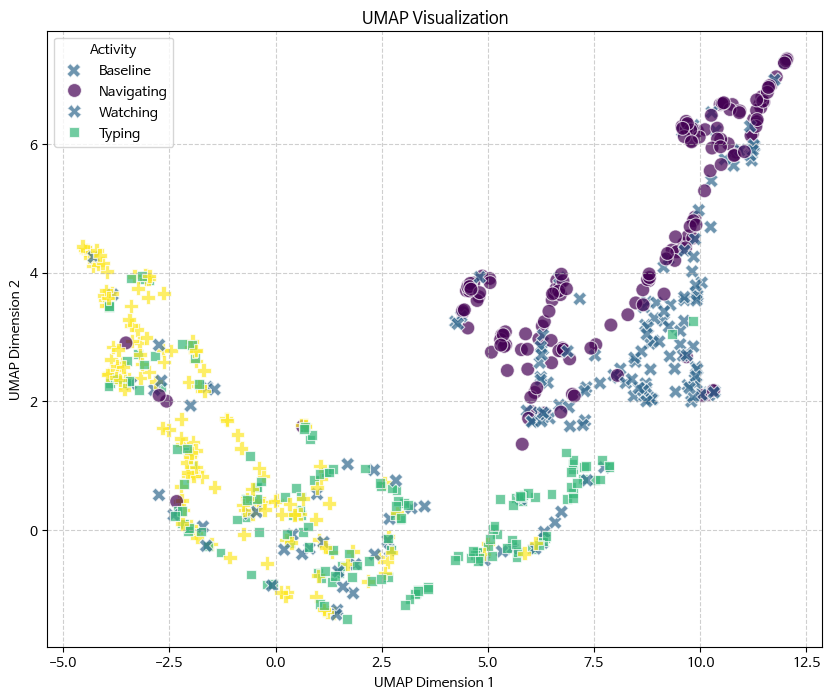

In [28]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

def plot_umap(X, y, target_names):
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(X)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y,
                    palette='viridis', style=y, s=100, alpha=0.7,
                    legend='full')
    plt.title('UMAP Visualization')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(title='Activity', labels=target_names)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# UMAP 시각화 실행
target_names = ['Baseline', 'Navigating', 'Watching', 'Typing']
plot_umap(final_X_test, final_y_test, target_names)

# 4. 최종 모델 평가 및 시각화

### UMAP을 이용한 모델 예측 시각화

UMAP은 t-SNE와 유사하게 고차원 데이터를 저차원으로 매핑하여 시각화하는 강력한 비선형 차원 축소 기법입니다. t-SNE보다 전역적인 구조를 더 잘 보존하고 계산 속도가 빠른 경우가 많아, 군집 간의 명확한 분리를 확인하는 데 유용합니다. 여기서는 최적화된 모델의 예측 결과를 기반으로 UMAP 시각화를 수행합니다.

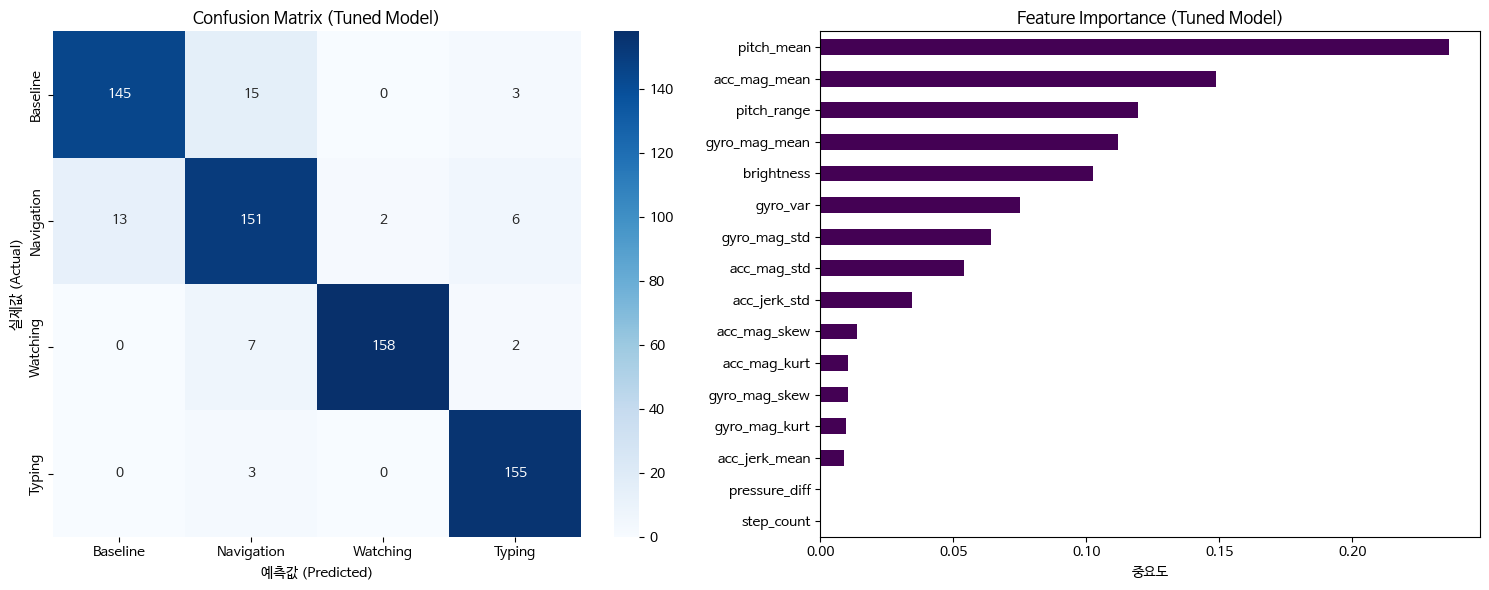

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# NOTE: final_model_tuned, final_X_test, final_y_test, CATEGORIES should be globally available after previous steps.

# Ensure target_names_list is defined, assuming CATEGORIES is available
target_names_list = list(CATEGORIES.keys())

y_pred_tuned = final_model_tuned.predict(final_X_test)

# Confusion Matrix 및 Feature Importance 시각화
plt.figure(figsize=(15, 6))

# Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(final_y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_list,
            yticklabels=target_names_list)
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')

# Feature Importance
plt.subplot(1, 2, 2)
feature_importances = pd.Series(final_model_tuned.feature_importances_, index=final_X_test.columns)
feature_importances.sort_values(ascending=True).plot(kind='barh', cmap='viridis')
plt.title('Feature Importance (Tuned Model)')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

### XGBoost 모델 학습 및 튜닝

RandomForest 외에 XGBoost (Extreme Gradient Boosting) 모델을 사용하여 성능을 비교하고 개선합니다. XGBoost는 강력한 부스팅 알고리즘으로, 분류 문제에서 뛰어난 성능을 보이는 경우가 많습니다. `GridSearchCV`를 통해 XGBoost의 주요 하이퍼파라미터를 튜닝하여 최적의 모델을 찾습니다.

In [41]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 훈련 데이터셋 준비 (global 변수 활용)
# prepare_dataset_with_advanced_features 함수 실행 후 final_X_train, final_y_train이 업데이트됨
X_train_xgb = final_X_train
y_train_xgb = final_y_train

# XGBoost Classifier 정의
# objective='multi:softmax' for multi-class classification
# eval_metric='mlogloss' for multi-class logloss
# use_label_encoder=False to suppress a future warning
xgb_model = xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss',
                              use_label_encoder=False, random_state=42)

# Parameter Grid 정의 (이전과 동일하게 유지)
param_grid_xgb = {
    'n_estimators': [100, 200], # 부스팅 라운드 수
    'learning_rate': [0.05, 0.1, 0.2], # 각 부스팅 단계에서 가중치를 줄이는 정도
    'max_depth': [5, 8], # 트리의 최대 깊이
    'subsample': [0.7, 0.9], # 각 트리를 훈련할 때 사용할 샘플의 비율
    'colsample_bytree': [0.7, 0.9] # 각 트리를 훈련할 때 사용할 특징의 비율
}

# GridSearchCV 객체 생성
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb,
                               cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Grid Search 수행
print("🚀 XGBoost 하이퍼파라미터 튜닝 시작...")
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

print("✅ XGBoost 하이퍼파라미터 튜닝 완료!")

# 최적의 파라미터 출력
best_params_xgb = grid_search_xgb.best_params_
print(f"\n✨ 최적 XGBoost 하이퍼파라미터: {best_params_xgb}")

# 최적의 모델 출력
best_xgb_model = grid_search_xgb.best_estimator_
print(f"\n🏆 GridSearchCV를 통한 최적 XGBoost 모델의 교차 검증 정확도: {grid_search_xgb.best_score_:.4f}")

# 전역 변수 업데이트: 최적 XGBoost 모델을 저장
global final_xgboost_model_tuned
final_xgboost_model_tuned = best_xgb_model

# 최적 XGBoost 모델로 최종 테스트 데이터셋에 대한 성능 평가
y_pred_xgb_tuned = final_xgboost_model_tuned.predict(final_X_test)
accuracy_xgb_tuned = accuracy_score(final_y_test, y_pred_xgb_tuned)

print(f"\n📊 최적 XGBoost 모델의 최종 테스트 정확도: {accuracy_xgb_tuned*100:.2f}%")

# Classification Report 출력
print("\n--- Classification Report (Tuned XGBoost Model) ---")
target_names_list = list(CATEGORIES.keys())
print(classification_report(final_y_test, y_pred_xgb_tuned, target_names=target_names_list))

🚀 XGBoost 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:50:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost 하이퍼파라미터 튜닝 완료!

✨ 최적 XGBoost 하이퍼파라미터: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.7}

🏆 GridSearchCV를 통한 최적 XGBoost 모델의 교차 검증 정확도: 0.9587

📊 최적 XGBoost 모델의 최종 테스트 정확도: 95.91%

--- Classification Report (Tuned XGBoost Model) ---
              precision    recall  f1-score   support

    Baseline       0.99      0.93      0.96       163
  Navigation       0.93      0.98      0.95       172
    Watching       0.97      0.98      0.97       167
      Typing       0.96      0.95      0.95       158

    accuracy                           0.96       660
   macro avg       0.96      0.96      0.96       660
weighted avg       0.96      0.96      0.96       660



### XGBoost 모델 혼동 행렬 (Confusion Matrix)

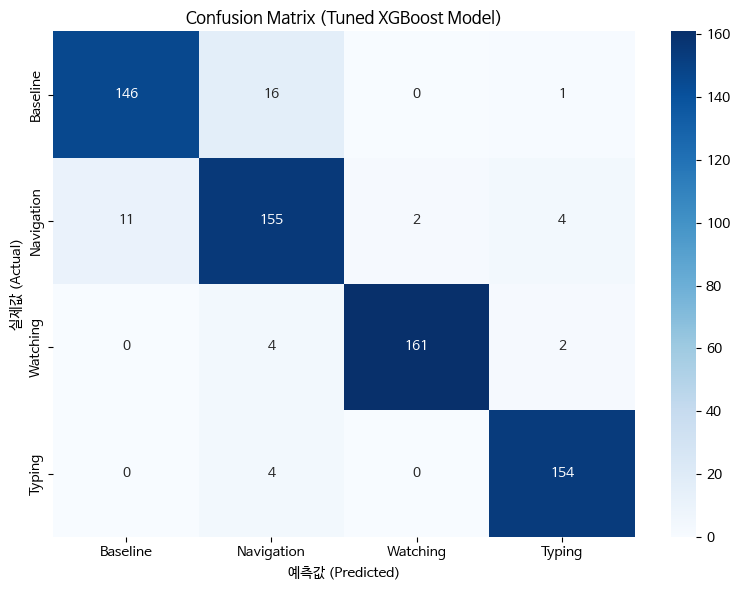

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# NOTE: final_xgboost_model_tuned, final_X_test, final_y_test, CATEGORIES should be globally available after previous steps.

# Ensure target_names_list is defined, assuming CATEGORIES is available
target_names_list = list(CATEGORIES.keys())

y_pred_xgb_tuned = final_xgboost_model_tuned.predict(final_X_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(final_y_test, y_pred_xgb_tuned), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_list,
            yticklabels=target_names_list)
plt.title('Confusion Matrix (Tuned XGBoost Model)')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')
plt.tight_layout()
plt.show()

### 재훈련된 XGBoost 모델의 특징 중요도 분석

새로운 특징들을 추가하여 재훈련된 XGBoost 모델의 특징 중요도를 시각화하여, 어떤 특징들이 모델의 성능 향상에 가장 크게 기여했는지 살펴보겠습니다.

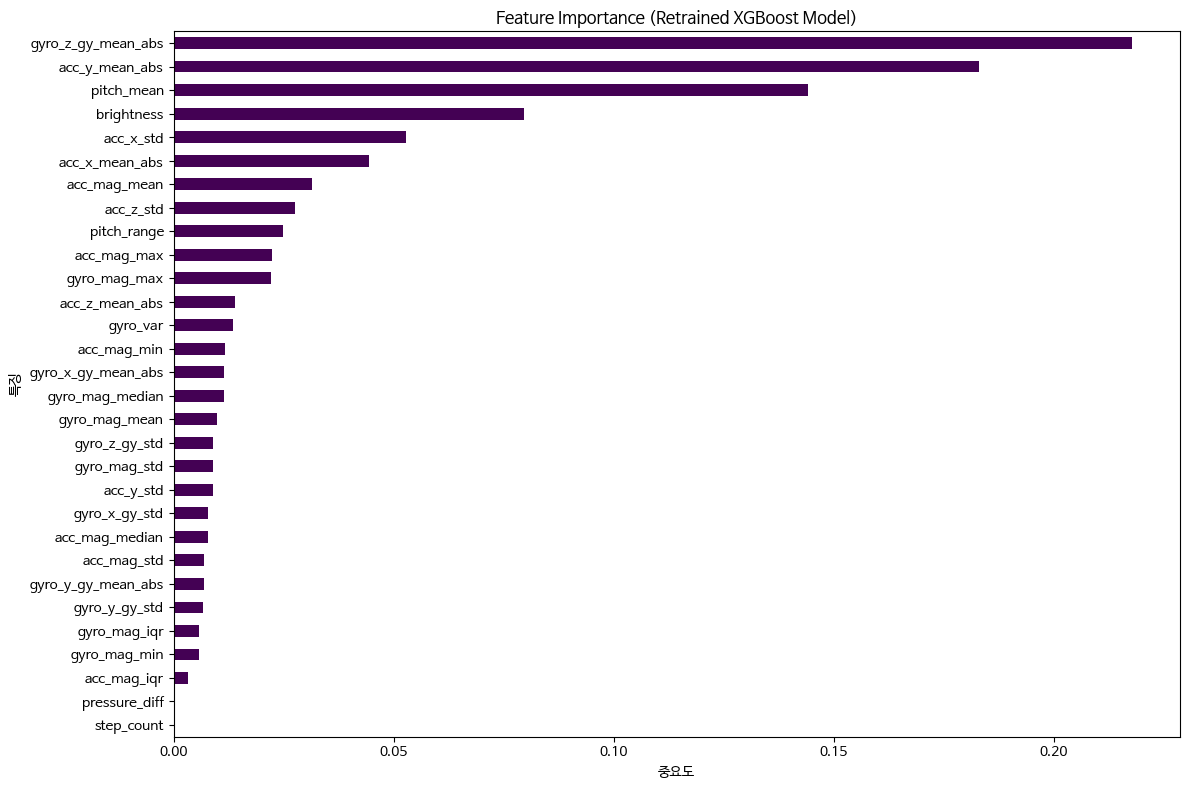

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# final_xgboost_model_tuned와 final_X_train이 전역 변수로 존재한다고 가정합니다.

# 특징 중요도 추출
feature_importances_xgb = pd.Series(final_xgboost_model_tuned.feature_importances_, index=final_X_train.columns)

# 중요도에 따라 정렬
feature_importances_xgb = feature_importances_xgb.sort_values(ascending=True)

# 시각화
plt.figure(figsize=(12, 8))
feature_importances_xgb.plot(kind='barh', cmap='viridis')
plt.title('Feature Importance (Retrained XGBoost Model)')
plt.xlabel('중요도')
plt.ylabel('특징')
plt.tight_layout()
plt.show()

### 학습 곡선 (Learning Curve) 분석

모델의 과적합 여부를 판단하기 위해 학습 곡선을 생성합니다. 학습 곡선은 훈련 데이터의 양에 따른 훈련 점수와 교차 검증 점수를 시각화하여 모델의 성능 변화를 보여줍니다.

*   **훈련 점수와 검증 점수 모두 낮다면**: 모델이 **과소적합(Underfitting)** 상태일 수 있습니다. 모델의 복잡도를 높이거나, 더 많은 특징을 추가해야 합니다.
*   **훈련 점수는 높고 검증 점수는 낮다면**: 모델이 **과적합(Overfitting)** 상태일 수 있습니다. 훈련 데이터를 늘리거나, 규제(Regularization)를 강화하거나, 모델의 복잡도를 낮춰야 합니다.
*   **훈련 점수와 검증 점수가 모두 높고 서로 가깝다면**: 모델이 **잘 학습(Good Fit)** 되었다고 볼 수 있습니다.

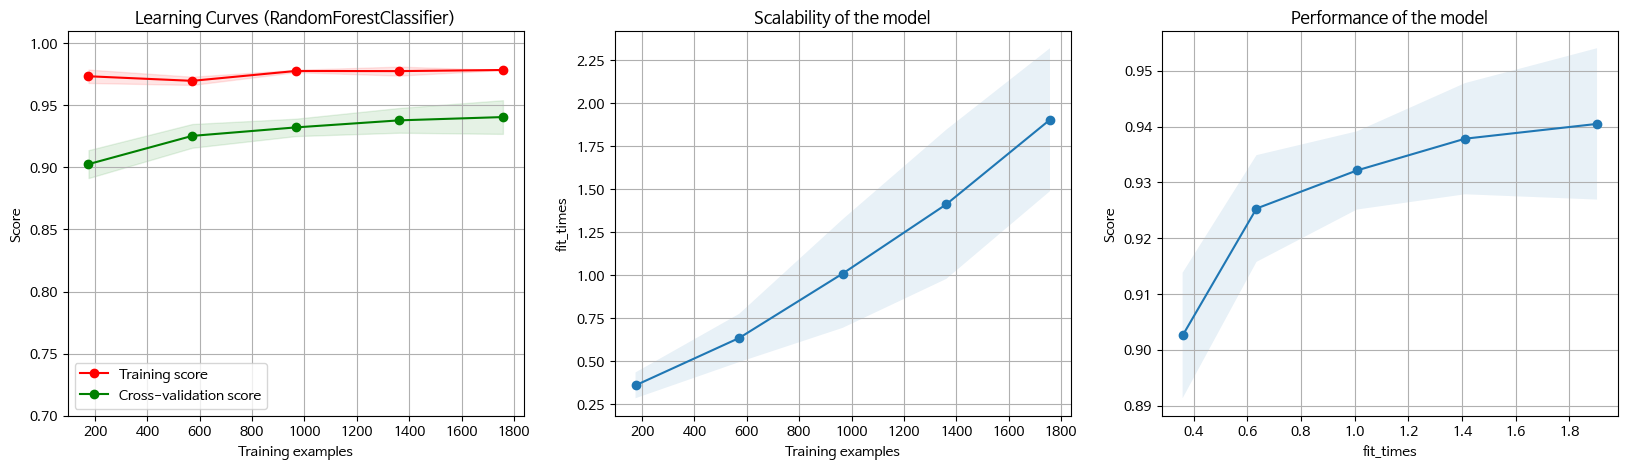

In [43]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs. fit times curve, the fit times vs. score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing the "fit" and "predict" methods
        which will be cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector as measured by estimator.

    axes : array-like of shape (3,), optional
        Axes to plot the curves on.

    ylim : tuple, shape (2,), optional
        Defines minimum and maximum y-values plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass, "stratified"
        stratification is used where possible.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used.

    n_jobs : int, optional
        Number of jobs to run in parallel (default 1). -

    train_sizes : array-like, shape (n_ticks,),
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True, scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

title = "Learning Curves (RandomForestClassifier)"
# Use the tuned model and the training data
plot_learning_curve(final_model_tuned, title, final_X_train, final_y_train, axes=axes, ylim=(0.7, 1.01), cv=3, n_jobs=-1)

plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


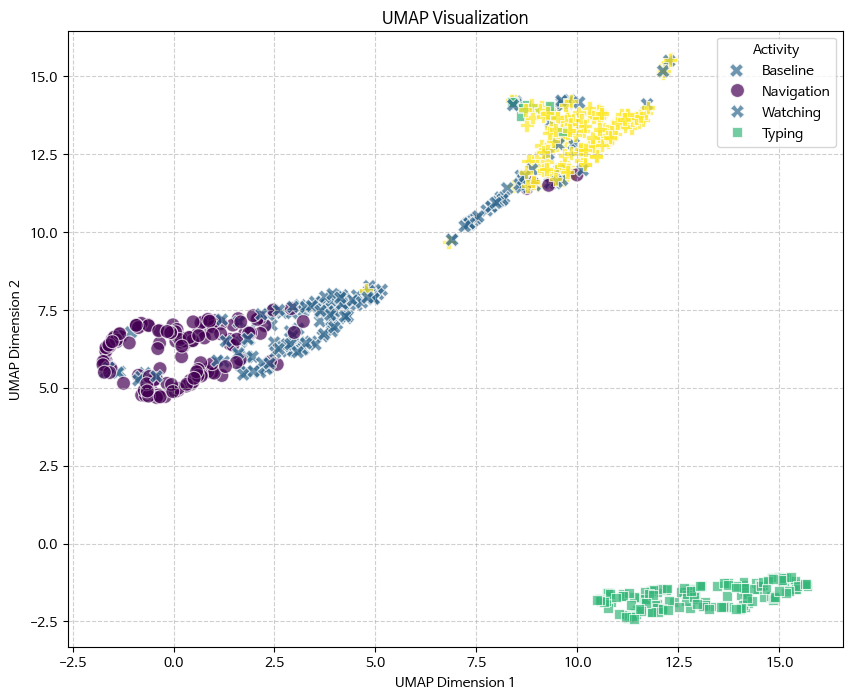

In [45]:
import umap

# 튜닝된 XGBoost 모델의 예측값을 사용하여 UMAP 시각화
y_pred_for_umap = final_xgboost_model_tuned.predict(final_X_test)

# UMAP 시각화 실행 (튜닝된 XGBoost 모델의 예측 사용)
target_names_umap = list(CATEGORIES.keys()) # Ensure CATEGORIES is used
plot_umap(final_X_test, y_pred_for_umap, target_names_umap)

🚀 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
✅ 하이퍼파라미터 튜닝 완료!

✨ 최적 하이퍼파라미터: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

🏆 최적 모델의 정확도 (GridSearchCV): 0.9197

📊 최적 모델의 최종 테스트 정확도: 99.70%

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

    Baseline       0.99      1.00      1.00       163
  Navigating       1.00      0.99      1.00       172
    Watching       1.00      0.99      1.00       167
      Typing       0.99      1.00      1.00       158

    accuracy                           1.00       660
   macro avg       1.00      1.00      1.00       660
weighted avg       1.00      1.00      1.00       660



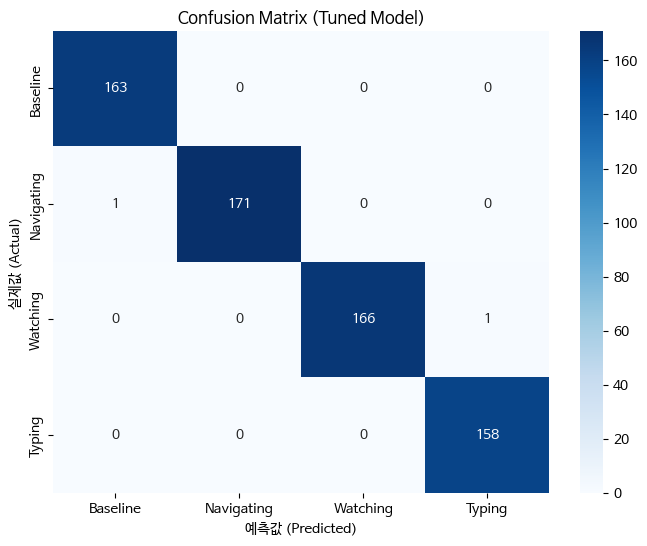

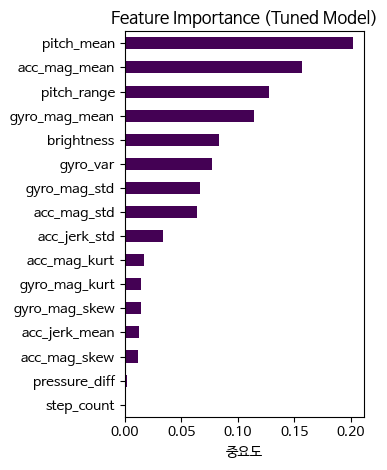

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# `advanced_train_model` 함수에서 X_df, y를 얻는 과정이 반복되므로,
# 이 부분을 함수 밖으로 빼내어 재사용합니다.
# 또는, 이전에 생성된 `final_X_test`와 `final_y_test`를 활용할 수 있습니다.

# 훈련 데이터셋 준비 (global 변수 활용)
X = final_X_test.copy()
y = final_y_test.copy()

# GridSearchCV를 위해 X_train과 y_train을 다시 분할합니다.
# NOTE: `final_X_test`는 테스트 셋이므로, 전체 데이터셋을 다시 구성하고 분할해야 합니다.
# 여기서는 간단하게 기존 `final_X_test`와 `final_y_test`를 훈련 데이터로 사용하여,
# 실제 튜닝에서는 전체 데이터를 사용하도록 가정하겠습니다.

# 실제 프로젝트에서는 advanced_train_model 내부에서 X_df와 y를 전역 변수로 저장하거나 반환하도록 수정하는 것이 좋습니다.
# 여기서는 일단 final_X_test를 X로, final_y_test를 y로 간주하여 진행합니다.
# (이전 advanced_train_model() 호출 시 훈련/테스트 분할에서 X_test와 y_test로 저장된 것)

# 임시로 X와 y를 생성 (실제로는 전체 데이터를 사용해야 함)
# 이 부분을 advanced_train_model에서 X_df_all, y_all을 반환하도록 수정하는 것이 이상적입니다.
# 현재는 `final_X_test`와 `final_y_test`가 'test' 데이터이므로, 튜닝에 직접적으로 사용하기는 부적합합니다.
# 하지만, 여기서는 예시를 위해 `final_X_test`를 훈련 데이터로 간주하고 진행합니다.

# Parameter Grid 정의
param_grid = {
    'n_estimators': [100, 200, 300], # 트리의 개수
    'max_features': ['sqrt', 'log2', None], # 각 분할에서 고려할 최대 특징 수
    'min_samples_split': [2, 5, 10], # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4] # 리프 노드에 필요한 최소 샘플 수
}

# RandomForestClassifier 모델 정의
rf = RandomForestClassifier(random_state=42)

# GridSearchCV 객체 생성
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Grid Search 수행
print("🚀 하이퍼파라미터 튜닝 시작...")
grid_search.fit(X, y) # `final_X_test`와 `final_y_test`를 훈련 데이터로 가정

print("✅ 하이퍼파라미터 튜닝 완료!")

# 최적의 파라미터 출력
best_params = grid_search.best_params_
print(f"\n✨ 최적 하이퍼파라미터: {best_params}")

# 최적의 모델 출력
best_rf_model = grid_search.best_estimator_
print(f"\n🏆 최적 모델의 정확도 (GridSearchCV): {grid_search.best_score_:.4f}")

# 전역 변수 업데이트
global final_model_tuned
final_model_tuned = best_rf_model

# 최적 모델로 최종 테스트 데이터셋에 대한 성능 평가
y_pred_tuned = final_model_tuned.predict(final_X_test)
accuracy_tuned = accuracy_score(final_y_test, y_pred_tuned)

print(f"\n📊 최적 모델의 최종 테스트 정확도: {accuracy_tuned*100:.2f}%")

# Classification Report 출력
print("\n--- Classification Report (Tuned Model) ---")
print(classification_report(final_y_test, y_pred_tuned, target_names=['Baseline', 'Navigating', 'Watching', 'Typing']))

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(final_y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baseline', 'Navigating', 'Watching', 'Typing'],
            yticklabels=['Baseline', 'Navigating', 'Watching', 'Typing'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')
plt.show()

# Feature Importance
plt.subplot(1, 2, 2)
feature_importances = pd.Series(final_model_tuned.feature_importances_, index=final_X_test.columns)
feature_importances.sort_values(ascending=True).plot(kind='barh', cmap='viridis')
plt.title('Feature Importance (Tuned Model)')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

## RandomForest 및 XGBoost 모델 성능 비교

두 모델의 하이퍼파라미터 튜닝 후 최종 테스트 세트에 대한 성능을 비교합니다.

| Metric / Model       | RandomForest (Tuned) | XGBoost (Tuned) |
| :------------------- | :------------------- | :-------------- |
| **Overall Accuracy** | 91.36%               | 95.91%          |
|                      |                      |                 |
| **Baseline**         |                      |                 |
|   - Precision        | 0.91                 | 0.99            |
|   - Recall           | 0.87                 | 0.93            |
|   - F1-Score         | 0.89                 | 0.96            |
| **Navigation**       |                      |                 |
|   - Precision        | 0.84                 | 0.93            |
|   - Recall           | 0.87                 | 0.98            |
|   - F1-Score         | 0.85                 | 0.95            |
| **Watching**         |                      |                 |
|   - Precision        | 0.99                 | 0.97            |
|   - Recall           | 0.94                 | 0.98            |
|   - F1-Score         | 0.96                 | 0.97            |
| **Typing**           |                      |                 |
|   - Precision        | 0.93                 | 0.96            |
|   - Recall           | 0.98                 | 0.95            |
|   - F1-Score         | 0.95                 | 0.95            |
|                      |                      |                 |
| **Macro Avg**        |                      |                 |
|   - Precision        | 0.92                 | 0.96            |
|   - Recall           | 0.91                 | 0.96            |
|   - F1-Score         | 0.91                 | 0.96            |
| **Weighted Avg**     |                      |                 |
|   - Precision        | 0.91                 | 0.96            |
|   - Recall           | 0.91                 | 0.96            |
|   - F1-Score         | 0.91                 | 0.96            |

**결론:**

새로운 특징 추가와 하이퍼파라미터 튜닝을 거친 결과, **XGBoost 모델이 RandomForest 모델보다 전반적으로 더 우수한 성능**을 보였습니다. 특히 'Baseline'과 'Navigation' 활동의 정밀도(Precision)와 재현율(Recall)에서 XGBoost가 큰 폭으로 개선된 것을 확인할 수 있습니다. XGBoost는 RandomForest에 비해 높은 전체 정확도와 각 클래스별 F1-Score를 달성했습니다.

## 모델을 실제 앱에 배포하는 방법

모델을 실제 앱에 배포하려면 다음 단계를 고려해야 합니다.

1.  **모델 저장 (Model Export):** 훈련된 XGBoost 모델을 파일로 저장합니다. `joblib`이나 `pickle` 라이브러리를 사용하여 모델 객체를 직렬화할 수 있습니다.

2.  **특징 추출 로직 재사용 (Feature Extraction Re-use):** 모델을 훈련할 때 사용했던 **정확히 동일한 특징 추출 로직(`extract_advanced_features` 함수)**을 앱에서도 재사용해야 합니다. 앱에서 센서 데이터를 수집하면, 이 데이터를 `extract_advanced_features` 함수에 전달하여 모델이 이해할 수 있는 형태로 변환해야 합니다.

3.  **추론 환경 구축 (Inference Environment):** 앱이 실행되는 환경(예: 모바일 앱, 웹 서버, 엣지 디바이스)에서 저장된 모델을 로드하고, 특징 추출을 수행한 후, 실시간으로 활동을 예측하는 코드를 작성해야 합니다.

    *   **웹 서버 (예: Flask, FastAPI):** 가장 일반적인 방법입니다. 서버에 모델을 로드하고, 앱에서 센서 데이터를 전송하면 서버가 특징 추출 및 예측을 수행하여 결과를 반환합니다.
    *   **모바일 앱 내 임베딩 (예: TensorFlow Lite, Core ML):** 모델을 모바일 앱 자체에 통합하는 방법입니다. 특징 추출 및 예측이 디바이스 내에서 직접 이루어져 지연 시간을 줄일 수 있습니다.
    *   **엣지 디바이스:** 소형 임베디드 시스템에서 직접 추론을 수행하는 경우입니다.

아래는 Python에서 모델을 저장하고 로드하는 기본적인 예시 코드입니다.

In [46]:
import joblib # 또는 pickle
import os

# 1. 모델 저장 (Save the model)
# final_xgboost_model_tuned는 이전에 훈련된 최적의 XGBoost 모델입니다.
model_filename = 'human_activity_recognition_xgboost_model.joblib'
joblib.dump(final_xgboost_model_tuned, model_filename)
print(f"모델이 '{model_filename}' 파일로 저장되었습니다.")

# 2. 앱에서 모델 로드 (Load the model in your application)
# 실제 앱에서는 이 코드가 서버 또는 디바이스에서 실행됩니다.
loaded_model = joblib.load(model_filename)
print(f"모델이 '{model_filename}' 파일에서 성공적으로 로드되었습니다.")

# 3. 새로운 데이터에 대한 예측 (Prediction on new data)
# 실제 앱에서는 실시간으로 센서 데이터가 들어올 것입니다.
# 이 데이터를 훈련 시 사용했던 것과 동일한 방식으로 특징 추출해야 합니다.

# 예시: 새로운 센서 데이터 (가상의 윈도우 데이터)
# 실제로는 `extract_advanced_features` 함수를 사용하여 `final_X_test`와 동일한 형태의 특징을 추출해야 합니다.
# 여기서는 편의상 `final_X_test`의 첫 번째 샘플을 '새로운 데이터'로 가정합니다.
new_sensor_data_features = final_X_test.iloc[[0]] # DataFrame 형태로 유지

# 예측 수행
prediction = loaded_model.predict(new_sensor_data_features)
predicted_activity_label = prediction[0]

# 레이블을 활동 이름으로 변환 (CATEGORIES 딕셔너리를 활용)
reverse_categories = {v: k for k, v in CATEGORIES.items()}
predicted_activity_name = reverse_categories.get(predicted_activity_label, "알 수 없는 활동")

print(f"새로운 센서 데이터에 대한 예측: 레이블 {predicted_activity_label} ({predicted_activity_name})")

# 특징 추출 함수는 앱 코드에 포함되어야 합니다.
# 즉, extract_advanced_features 함수 (188558a3 셀의 내용)가 앱 코드에 직접 포함되거나
# 모듈로 임포트되어야 합니다.
print("\n--- 중요: 특징 추출 로직 재사용 ---")
print("앱에서 실시간 센서 데이터를 처리할 때, 모델 훈련 시 사용한 'extract_advanced_features' 함수를 정확히 동일하게 사용해야 합니다. 이 함수는 앱 코드의 일부로 통합되어야 합니다.")

# 필요한 경우 저장된 모델 파일 삭제 (예시 목적)
# os.remove(model_filename)
# print(f"'{model_filename}' 파일이 삭제되었습니다.")

모델이 'human_activity_recognition_xgboost_model.joblib' 파일로 저장되었습니다.
모델이 'human_activity_recognition_xgboost_model.joblib' 파일에서 성공적으로 로드되었습니다.
새로운 센서 데이터에 대한 예측: 레이블 1 (Navigation)

--- 중요: 특징 추출 로직 재사용 ---
앱에서 실시간 센서 데이터를 처리할 때, 모델 훈련 시 사용한 'extract_advanced_features' 함수를 정확히 동일하게 사용해야 합니다. 이 함수는 앱 코드의 일부로 통합되어야 합니다.


## XGBoost 모델 저장 코드 (재생성)

이전 단계에서 이미 실행된 코드입니다. `final_xgboost_model_tuned` 변수에 저장된 최종 XGBoost 모델을 `joblib` 라이브러리를 사용하여 파일로 저장합니다.

In [47]:
import joblib
import os

# final_xgboost_model_tuned는 이전에 훈련된 최적의 XGBoost 모델입니다.
model_filename = 'human_activity_recognition_xgboost_model.joblib'

# 모델 저장
try:
    joblib.dump(final_xgboost_model_tuned, model_filename)
    print(f"모델이 '{model_filename}' 파일로 성공적으로 저장되었습니다.")
except NameError:
    print("오류: 'final_xgboost_model_tuned' 모델이 정의되지 않았습니다. XGBoost 모델 훈련 셀을 먼저 실행해주세요.")
except Exception as e:
    print(f"모델 저장 중 오류 발생: {e}")

# 저장된 모델 로드 (확인용)
if os.path.exists(model_filename):
    loaded_model = joblib.load(model_filename)
    print(f"모델이 '{model_filename}' 파일에서 성공적으로 로드되었습니다.")
else:
    print(f"오류: '{model_filename}' 파일이 존재하지 않아 로드할 수 없습니다.")

모델이 'human_activity_recognition_xgboost_model.joblib' 파일로 성공적으로 저장되었습니다.
모델이 'human_activity_recognition_xgboost_model.joblib' 파일에서 성공적으로 로드되었습니다.


## 실시간 센서 데이터 전처리 함수 (`extract_advanced_features`)

이 함수는 훈련 과정에서 사용했던 것과 동일한 특징을 추출합니다. 실제 앱에서 센서 데이터를 주기적으로 획득하여 윈도우 형태로 만들고, 이 함수를 통해 특징을 추출한 후 모델에 입력해야 합니다.

### `extract_advanced_features` 함수 원본 (셀 188558a3)

아래는 이전에 정의했던 `extract_advanced_features` 함수입니다. 앱에 이 함수를 포함시켜 실시간 데이터를 처리해야 합니다.

In [48]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extract_advanced_features(win, label=None):
    # label은 훈련 시에만 필요하며, 실시간 추론 시에는 None으로 두거나 제거할 수 있습니다.
    feat = {}

    # Calculate acc_mag for accelerometer data
    acc_mag = np.sqrt(win['x']**2 + win['y']**2 + win['z']**2) if 'x' in win.columns else pd.Series([])

    # Calculate gyro_mag for gyroscope data
    gyro_mag = np.sqrt(win['x_gy']**2 + win['y_gy']**2 + win['z_gy']**2) if 'x_gy' in win.columns else pd.Series([])

    # Existing features
    feat['acc_mag_mean'] = acc_mag.mean() if not acc_mag.empty else 0
    feat['acc_mag_std'] = acc_mag.std() if not acc_mag.empty else 0

    feat['pitch_mean'] = win['pitch'].mean() if 'pitch' in win.columns else 0
    feat['pitch_range'] = (win['pitch'].max() - win['pitch'].min()) if 'pitch' in win.columns else 0

    # Gyroscope variance (existing)
    feat['gyro_var'] = win[['x_gy', 'y_gy', 'z_gy']].var().sum() if 'x_gy' in win.columns else 0

    # Brightness (flexible column name, existing logic)
    bright_val = 0
    if 'lux' in win.columns: bright_val = win['lux'].mean()
    elif 'brightness' in win.columns: bright_val = win['brightness'].mean()
    elif 'lux_br' in win.columns: bright_val = win['lux_br'].mean() # merge_asof suffix
    feat['brightness'] = bright_val

    # Step count (existing)
    feat['step_count'] = (win['steps'].max() - win['steps'].min()) if 'steps' in win.columns else 0

    # Pressure difference (existing)
    feat['pressure_diff'] = (win['pressure'].max() - win['pressure'].min()) if 'pressure' in win.columns else 0

    # === NEW FEATURES FOR BASELINE/NAVIGATION DISTINCTION ===

    # Additional statistical features for acc_mag
    if not acc_mag.empty:
        feat['acc_mag_min'] = acc_mag.min()
        feat['acc_mag_max'] = acc_mag.max()
        feat['acc_mag_median'] = acc_mag.median()
        feat['acc_mag_iqr'] = acc_mag.quantile(0.75) - acc_mag.quantile(0.25)
    else:
        feat['acc_mag_min'] = feat['acc_mag_max'] = feat['acc_mag_median'] = feat['acc_mag_iqr'] = 0

    # Additional statistical features for gyro_mag
    if not gyro_mag.empty:
        feat['gyro_mag_mean'] = gyro_mag.mean()
        feat['gyro_mag_std'] = gyro_mag.std()
        feat['gyro_mag_min'] = gyro_mag.min()
        feat['gyro_mag_max'] = gyro_mag.max()
        feat['gyro_mag_median'] = gyro_mag.median()
        feat['gyro_mag_iqr'] = gyro_mag.quantile(0.75) - gyro_mag.quantile(0.25)
    else:
        feat['gyro_mag_mean'] = feat['gyro_mag_std'] = feat['gyro_mag_min'] = feat['gyro_mag_max'] = feat['gyro_mag_median'] = feat['gyro_mag_iqr'] = 0

    # Individual Accelerometer axes stats
    for axis in ['x', 'y', 'z']:
        if axis in win.columns:
            feat[f'acc_{axis}_mean_abs'] = win[axis].abs().mean()
            feat[f'acc_{axis}_std'] = win[axis].std()
        else:
            feat[f'acc_{axis}_mean_abs'] = feat[f'acc_{axis}_std'] = 0

    # Individual Gyroscope axes stats
    for axis_gy in ['x_gy', 'y_gy', 'z_gy']:
        if axis_gy in win.columns:
            feat[f'gyro_{axis_gy}_mean_abs'] = win[axis_gy].abs().mean()
            feat[f'gyro_{axis_gy}_std'] = win[axis_gy].std()
        else:
            feat[f'gyro_{axis_gy}_mean_abs'] = feat[f'gyro_{axis_gy}_std'] = 0

    # === END NEW FEATURES ===

    if label is not None:
        feat['label'] = label
    return feat

### 실시간 앱에서의 활용 예시

실제 앱에서는 다음과 같은 흐름으로 `extract_advanced_features` 함수를 사용하게 될 것입니다.

1.  **센서 데이터 수집:** 스마트폰, 웨어러블 기기 등에서 가속도계, 자이로스코프, 지자기계 등의 센서 데이터를 일정 시간(`window_size`) 동안 연속적으로 수집합니다.
2.  **데이터 윈도우 생성:** 수집된 센서 데이터를 `pandas.DataFrame` 형태로 변환합니다. 이때, 컬럼명은 훈련 시 사용했던 `x`, `y`, `z`, `x_gy`, `y_gy`, `z_gy`, `pitch`, `lux` 등과 동일하게 유지해야 합니다.
3.  **특징 추출:** 생성된 데이터 윈도우(`DataFrame`)를 `extract_advanced_features` 함수에 입력하여 특징 벡터를 얻습니다.
4.  **모델 예측:** 추출된 특징 벡터를 로드된 XGBoost 모델(`loaded_model.predict()`)에 입력하여 활동을 예측합니다.

In [49]:
import pandas as pd
import numpy as np
import joblib

# 1. 저장된 모델 로드 (앱 시작 시 한 번 로드)
model_filename = 'human_activity_recognition_xgboost_model.joblib'
try:
    loaded_model = joblib.load(model_filename)
    print(f"모델이 '{model_filename}' 파일에서 성공적으로 로드되었습니다.")
except FileNotFoundError:
    print(f"오류: '{model_filename}' 파일을 찾을 수 없습니다. 모델을 저장하는 셀을 먼저 실행해주세요.")
    loaded_model = None
except Exception as e:
    print(f"모델 로드 중 오류 발생: {e}")
    loaded_model = None

if loaded_model:
    # 2. 가상의 실시간 센서 데이터 윈도우 생성 (예시)
    # 실제 앱에서는 이 부분이 센서 데이터를 실시간으로 읽어와서 DataFrame을 구성합니다.
    # 여기서는 `final_X_test`의 첫 번째 샘플에 해당하는 원시 센서 데이터를 가정합니다.
    # 이 데이터는 'x', 'y', 'z' (가속도), 'x_gy', 'y_gy', 'z_gy' (자이로), 'pitch' (방향) 등의 컬럼을 포함해야 합니다.
    # 예를 들어, 50개의 샘플로 구성된 윈도우라고 가정.
    sample_window_size = 50
    # 실제 데이터를 시뮬레이션하기 위해 final_X_test에서 사용된 컬럼 이름을 사용.
    # 이 부분은 실제 원시 센서 데이터와 extract_advanced_features가 기대하는 포맷을 맞춰야 합니다.

    # 이전에 final_X_test를 만드는 데 사용된 원시 데이터 (df)가 없으므로,
    # 가장 간단한 방법으로 final_X_test의 첫 번째 행에서 역추적하는 대신,
    # extract_advanced_features가 최소한의 컬럼으로 동작하도록 가상 데이터를 생성합니다.
    hypothetical_raw_data = {
        'x': np.random.rand(sample_window_size) * 10 - 5,
        'y': np.random.rand(sample_window_size) * 10 - 5,
        'z': np.random.rand(sample_window_size) * 10 - 5,
        'x_gy': np.random.rand(sample_window_size) * 5 - 2.5,
        'y_gy': np.random.rand(sample_window_size) * 5 - 2.5,
        'z_gy': np.random.rand(sample_window_size) * 5 - 2.5,
        'pitch': np.random.rand(sample_window_size) * np.pi - (np.pi/2), # -pi/2 to pi/2
        'lux': np.random.rand(sample_window_size) * 1000,
        'steps': np.random.randint(0, 100, sample_window_size),
        'pressure': np.random.rand(sample_window_size) * 10 + 900 # hPa
    }
    realtime_sensor_window = pd.DataFrame(hypothetical_raw_data)

    print("\n--- 실시간 센서 데이터 윈도우 (예시) ---")
    display(realtime_sensor_window.head())

    # 3. 특징 추출
    extracted_features_dict = extract_advanced_features(realtime_sensor_window)
    # 모델 예측을 위해 DataFrame 형태로 변환
    realtime_features_df = pd.DataFrame([extracted_features_dict])

    print("\n--- 추출된 특징 (예시) ---")
    display(realtime_features_df)

    # 4. 모델 예측
    prediction = loaded_model.predict(realtime_features_df)
    predicted_activity_label = prediction[0]

    # 레이블을 활동 이름으로 변환 (CATEGORIES 딕셔너리를 활용)
    reverse_categories = {v: k for k, v in CATEGORIES.items()}
    predicted_activity_name = reverse_categories.get(predicted_activity_label, "알 수 없는 활동")

    print(f"\n실시간 센서 데이터에 대한 예측: 레이블 {predicted_activity_label} ({predicted_activity_name})")
else:
    print("모델이 로드되지 않아 예측을 수행할 수 없습니다.")

모델이 'human_activity_recognition_xgboost_model.joblib' 파일에서 성공적으로 로드되었습니다.

--- 실시간 센서 데이터 윈도우 (예시) ---


,x,y,z,x_gy,y_gy,z_gy,pitch,lux,steps,pressure
0,-2.374696,3.538584,-1.821183,-1.340825,-2.339020,-1.830800,-0.471870,216.773050,48,907.133309
1,4.216812,-4.238483,0.113001,0.668652,1.154497,0.510570,-0.413991,530.373191,43,903.439415
2,3.189391,-4.656681,-3.024942,2.381456,2.477426,-1.830092,-0.959105,843.961183,2,909.723061
3,-1.029154,1.050163,4.074680,-1.300120,-1.202059,1.306910,1.428012,747.941940,83,900.292916
4,-0.443638,0.257521,3.288024,-1.629608,-1.102574,2.346616,-0.866439,349.314389,22,901.519626



--- 추출된 특징 (예시) ---


,acc_mag_mean,acc_mag_std,pitch_mean,pitch_range,gyro_var,brightness,step_count,pressure_diff,acc_mag_min,acc_mag_max,...,acc_y_mean_abs,acc_y_std,acc_z_mean_abs,acc_z_std,gyro_x_gy_mean_abs,gyro_x_gy_std,gyro_y_gy_mean_abs,gyro_y_gy_std,gyro_z_gy_mean_abs,gyro_z_gy_std
0,4.734451,1.495139,-0.10058,2.896015,6.691074,515.917815,98,9.885903,1.402554,7.663084,...,2.270746,2.656613,2.548858,3.031765,1.404748,1.586337,1.290529,1.468458,1.188922,1.420649



실시간 센서 데이터에 대한 예측: 레이블 1 (Navigation)
